# 05 · Modelo final y evaluación

1. Elegir entre modelo único y ensemble **usando solo CV sobre `train_dev`**.
2. Entrenar la variante ganadora.
3. Evaluar **una única vez** sobre el test interno (176 filas nunca vistas).
4. Guardar pipeline + pesos + metadatos para `predict.py`.

In [1]:
import json, sys, time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

sys.path.insert(0, str(Path.cwd().parent))
from src.data import ROOT, load_raw, rmse, split_xy
from src.experiments import cv_multiseed
from src.model import ModelConfig, fit_mlp, predict_usd
from src.preprocessing import PreprocessConfig, build_preprocessor

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight"})
FIGURES, MODELS = ROOT / "reports" / "figures", ROOT / "models"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

df = load_raw(ROOT / "data" / "raw" / "train.csv")
X, y = split_xy(df)
split = json.loads((ROOT / "data" / "processed" / "split.json").read_text())
mejor = json.loads((ROOT / "data" / "processed" / "mejor_config.json").read_text())

mask_dev = df["Id"].isin(split["id_dev"]).to_numpy()
X_dev, y_dev = X[mask_dev].reset_index(drop=True), y[mask_dev].reset_index(drop=True)
X_test, y_test = X[~mask_dev].reset_index(drop=True), y[~mask_dev].reset_index(drop=True)
ids_dev = df.loc[mask_dev, "Id"].reset_index(drop=True)

CFG_PRE = PreprocessConfig(**mejor["pre"])
CFG_MLP = ModelConfig(**{**mejor["mlp"], "hidden": tuple(mejor["mlp"]["hidden"])})
EXCLUIR = np.array(mejor["excluir_ids"] or [])
mask_excluir = ids_dev.isin(EXCLUIR).to_numpy() if len(EXCLUIR) else None

print(f"Iteración ganadora : {mejor['id_iteracion']} (RMSE CV {mejor['val_rmse_cv']:,.0f})")
print(f"train_dev {X_dev.shape} | test interno {X_test.shape}")
print(f"Excluir del entrenamiento: {list(EXCLUIR) if len(EXCLUIR) else 'nada'}")

Iteración ganadora : it38 (RMSE CV 28,375)
train_dev (992, 79) | test interno (176, 79)
Excluir del entrenamiento: nada


## 1. ¿Modelo único o ensemble? (decidido en CV, sin tocar el test)

In [2]:
N_ENSEMBLE = 5
r_uno = cv_multiseed(X_dev, y_dev, CFG_PRE, CFG_MLP, semillas=(42, 43, 44), n_splits=5,
                     stratify=False, id="final_uno", descripcion="modelo único",
                     device=DEVICE, excluir_de_train=mask_excluir)
print(f"Modelo único : {r_uno.val_rmse:,.0f} ± {r_uno.val_std:,.0f}")

Modelo único : 30,282 ± 2,952


In [3]:
# Ensemble: dentro de cada fold se entrenan N modelos con semillas distintas y se promedian.
from sklearn.model_selection import KFold

def cv_ensemble(X, y, pre_cfg, mlp_cfg, n_modelos=5, semillas=(42, 43, 44), excluir=None):
    rmses = []
    for s in semillas:
        oof = np.full(len(y), np.nan)
        for i_tr, i_va in KFold(5, shuffle=True, random_state=s).split(X):
            if excluir is not None:
                i_tr = i_tr[~excluir[i_tr]]
            pre = build_preprocessor(pre_cfg)
            A = pre.fit_transform(X.iloc[i_tr], y.iloc[i_tr])
            B = pre.transform(X.iloc[i_va])
            y_tr, y_va = y.iloc[i_tr].to_numpy(), y.iloc[i_va].to_numpy()
            preds = []
            for m in range(n_modelos):
                cfg = ModelConfig(**{**mlp_cfg.to_dict(), "seed": mlp_cfg.seed + 100 * m + s})
                modelo, _ = fit_mlp(A, y_tr, B, y_va, cfg, device=DEVICE)
                preds.append(predict_usd(modelo, B, cfg, device=DEVICE))
            oof[i_va] = np.mean(preds, axis=0)
        rmses.append(rmse(y, oof))
    return float(np.mean(rmses)), float(np.std(rmses))

t0 = time.perf_counter()
ens_m, ens_s = cv_ensemble(X_dev, y_dev, CFG_PRE, CFG_MLP, n_modelos=N_ENSEMBLE,
                           excluir=mask_excluir)
print(f"Ensemble x{N_ENSEMBLE} : {ens_m:,.0f} ± {ens_s:,.0f}   ({time.perf_counter()-t0:.0f}s)")
print(f"\nGanancia del ensemble: {r_uno.val_rmse - ens_m:+,.0f} USD")

USAR_ENSEMBLE = (r_uno.val_rmse - ens_m) > 516     # umbral de mejora real del notebook 02
print(f"Decisión: {'ENSEMBLE' if USAR_ENSEMBLE else 'MODELO ÚNICO'}")

Ensemble x5 : 30,219 ± 3,597   (253s)

Ganancia del ensemble: +63 USD
Decisión: MODELO ÚNICO


## 2. Entrenamiento final sobre todo `train_dev`

In [4]:
# Se reserva un 12 % de train_dev solo para el early stopping. No se usa para elegir nada:
# todas las decisiones ya están tomadas.
from sklearn.model_selection import train_test_split

idx = np.arange(len(X_dev))
i_fit, i_es = train_test_split(idx, test_size=0.12, random_state=42)
if mask_excluir is not None:
    i_fit = i_fit[~mask_excluir[i_fit]]

pipeline = build_preprocessor(CFG_PRE)
A_fit = pipeline.fit_transform(X_dev.iloc[i_fit], y_dev.iloc[i_fit])
A_es = pipeline.transform(X_dev.iloc[i_es])
A_test = pipeline.transform(X_test)
print(f"ajuste {A_fit.shape} | early stopping {A_es.shape} | test interno {A_test.shape}")

modelos, historias = [], []
n_modelos = N_ENSEMBLE if USAR_ENSEMBLE else 1
for m in range(n_modelos):
    cfg = ModelConfig(**{**CFG_MLP.to_dict(), "seed": CFG_MLP.seed + 100 * m})
    modelo, h = fit_mlp(A_fit, y_dev.iloc[i_fit].to_numpy(), A_es, y_dev.iloc[i_es].to_numpy(),
                        cfg, device=DEVICE)
    modelos.append(modelo); historias.append(h)
    print(f"  modelo {m+1}/{n_modelos}: mejor época {h.best_epoch}, "
          f"RMSE es {h.best_val_rmse:,.0f}")

ajuste (872, 218) | early stopping (120, 218) | test interno (176, 218)


  modelo 1/1: mejor época 143, RMSE es 25,224


## 3. Evaluación única sobre el test interno

In [5]:
pred_test = np.mean([predict_usd(m, A_test, CFG_MLP, device=DEVICE) for m in modelos], axis=0)
pred_test = np.clip(pred_test, 0, None)
rmse_test = rmse(y_test, pred_test)

print("=" * 58)
print(f"RMSE sobre el test interno ({len(y_test)} viviendas nunca vistas)")
print("=" * 58)
print(f"  RMSE          : {rmse_test:,.0f} USD")
print(f"  RMSE en CV    : {mejor['val_rmse_cv']:,.0f} USD")
print(f"  diferencia    : {rmse_test - mejor['val_rmse_cv']:+,.0f} USD")
print(f"\n  MAE           : {np.mean(np.abs(y_test - pred_test)):,.0f} USD")
print(f"  error mediano : {np.median(np.abs(y_test - pred_test)):,.0f} USD")
print(f"  MAPE          : {np.mean(np.abs(y_test - pred_test) / y_test):.1%}")
print(f"  R²            : {1 - np.sum((y_test-pred_test)**2)/np.sum((y_test-y_test.mean())**2):.3f}")

RMSE sobre el test interno (176 viviendas nunca vistas)
  RMSE          : 24,197 USD
  RMSE en CV    : 28,375 USD
  diferencia    : -4,177 USD

  MAE           : 16,155 USD
  error mediano : 10,342 USD
  MAPE          : 9.0%
  R²            : 0.894


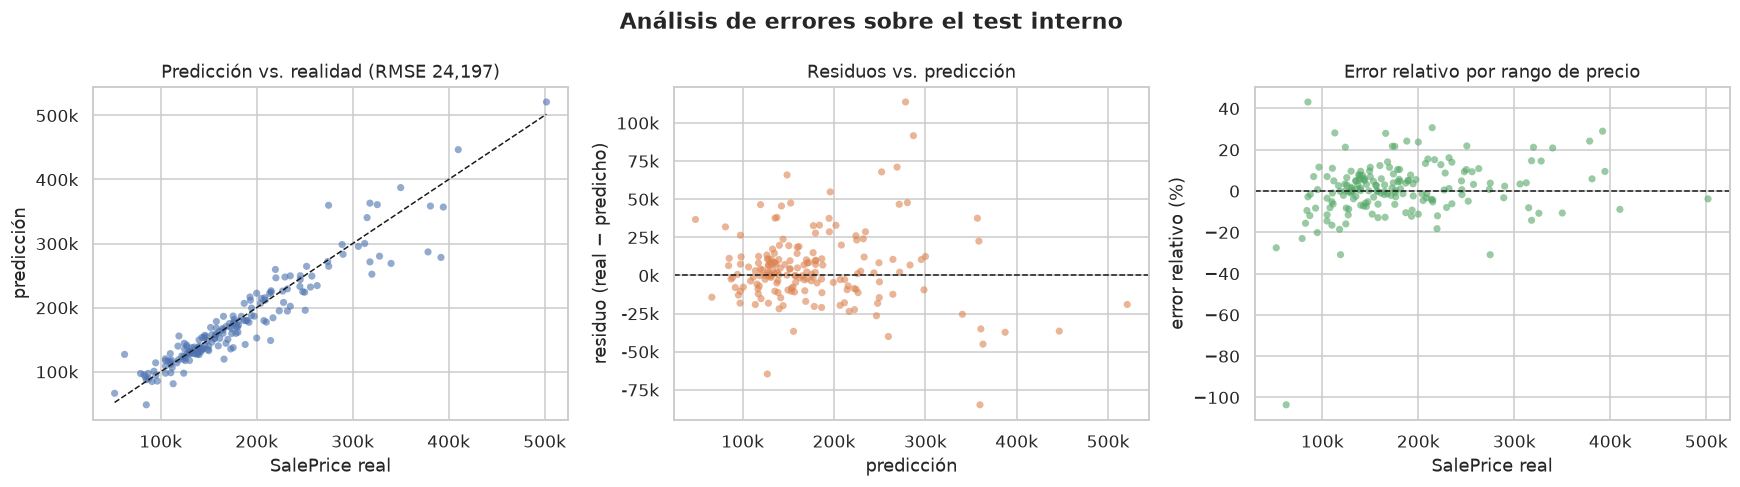

In [6]:
res = y_test - pred_test
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_test, pred_test, s=22, alpha=0.6, edgecolor="none", color="#4C72B0")
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, ls="--", color="k", lw=1)
axes[0].set_xlabel("SalePrice real"); axes[0].set_ylabel("predicción")
axes[0].set_title(f"Predicción vs. realidad (RMSE {rmse_test:,.0f})")

axes[1].scatter(pred_test, res, s=22, alpha=0.6, edgecolor="none", color="#DD8452")
axes[1].axhline(0, ls="--", color="k", lw=1)
axes[1].set_xlabel("predicción"); axes[1].set_ylabel("residuo (real − predicho)")
axes[1].set_title("Residuos vs. predicción")

axes[2].scatter(y_test, res / y_test * 100, s=22, alpha=0.6, edgecolor="none", color="#55A868")
axes[2].axhline(0, ls="--", color="k", lw=1)
axes[2].set_xlabel("SalePrice real"); axes[2].set_ylabel("error relativo (%)")
axes[2].set_title("Error relativo por rango de precio")

for ax in axes:
    ax.xaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
axes[0].yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
axes[1].yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")

fig.suptitle("Análisis de errores sobre el test interno", fontweight="bold")
fig.tight_layout(); fig.savefig(FIGURES / "18_analisis_errores.png"); plt.show()

In [7]:
# ¿Dónde falla más? Error por quintil de precio
q = pd.qcut(y_test, 5, labels=[f"Q{i}" for i in range(1, 6)])
por_q = pd.DataFrame({"real": y_test, "pred": pred_test, "quintil": q}).groupby(
    "quintil", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "precio medio": g["real"].mean(),
        "RMSE": rmse(g["real"], g["pred"]),
        "error relativo": np.mean(np.abs(g["real"] - g["pred"]) / g["real"]),
        "sesgo": np.mean(g["pred"] - g["real"]),
    }), include_groups=False)
por_q.round({"precio medio": 0, "RMSE": 0, "error relativo": 3, "sesgo": 0})

,n,precio medio,RMSE,error relativo,sesgo
quintil,,,,,
Q1,36.0,102641.0,18387.0,0.141,4904.0
Q2,35.0,136844.0,7655.0,0.047,-1613.0
Q3,35.0,164789.0,16285.0,0.071,-5909.0
Q4,35.0,202273.0,23192.0,0.088,-4983.0
Q5,35.0,301161.0,41652.0,0.103,-13377.0


## 4. Guardar artefactos para la competencia

In [8]:
MODELS.mkdir(exist_ok=True)

# El pipeline se reajusta con TODO train_dev (incluida la porción de early stopping):
# el día de la competencia conviene aprovechar cada observación disponible.
i_todo = np.arange(len(X_dev))
if mask_excluir is not None:
    i_todo = i_todo[~mask_excluir]
pipeline_final = build_preprocessor(CFG_PRE)
A_todo = pipeline_final.fit_transform(X_dev.iloc[i_todo], y_dev.iloc[i_todo])

# El seguimiento debe transformarse con ESTE pipeline, no con el anterior: al reajustarlo
# sobre un subconjunto distinto, la agrupación de categorías raras cambia el número de
# columnas y las matrices dejan de ser compatibles.
A_es_final = pipeline_final.transform(X_dev.iloc[i_es])
print(f"features: ajuste previo {A_fit.shape[1]} → pipeline final {A_todo.shape[1]}")

modelos_finales, epocas = [], int(np.median([h.best_epoch for h in historias])) + 1
for m in range(n_modelos):
    cfg = ModelConfig(**{**CFG_MLP.to_dict(), "seed": CFG_MLP.seed + 100 * m,
                         "max_epochs": epocas, "patience": epocas})
    modelo, _ = fit_mlp(A_todo, y_dev.iloc[i_todo].to_numpy(), A_es_final,
                        y_dev.iloc[i_es].to_numpy(), cfg, device=DEVICE)
    modelos_finales.append(modelo.cpu())

joblib.dump(pipeline_final, MODELS / "final_pipeline.joblib")
torch.save({
    "state_dict": modelos_finales[0].state_dict(),
    "y_mu": modelos_finales[0].y_mu_, "y_sigma": modelos_finales[0].y_sigma_,
    "ensemble": [{"state_dict": m.state_dict(), "y_mu": m.y_mu_, "y_sigma": m.y_sigma_}
                 for m in modelos_finales],
}, MODELS / "final_model.pt")

metadata = {
    "iteracion": mejor["id_iteracion"],
    "n_features": int(A_todo.shape[1]),
    "n_modelos": n_modelos,
    "epocas_entrenamiento": epocas,
    "pre_config": CFG_PRE.to_dict(),
    "model_config": CFG_MLP.to_dict(),
    "excluir_ids": [int(i) for i in EXCLUIR],
    "rmse_cv_train_dev": float(mejor["val_rmse_cv"]),
    "rmse_test_interno": float(rmse_test),
    "n_train": int(len(i_todo)),
    "lectura_csv": "keep_default_na=False, na_values=['']",
}
(MODELS / "metadata.json").write_text(json.dumps(metadata, indent=2, ensure_ascii=False))

print("Artefactos guardados en models/:")
for f in sorted(MODELS.glob("*")):
    if f.is_file():
        print(f"  {f.name:<24} {f.stat().st_size/1024:>8,.0f} KB")

features: ajuste previo 218 → pipeline final 218


Artefactos guardados en models/:
  .gitkeep                        0 KB
  final_model.pt                152 KB
  final_pipeline.joblib          16 KB
  metadata.json                   1 KB


## 5. Prueba de humo del flujo de la competencia

In [9]:
# Se simula el día de la presentación: el test interno se escribe como CSV nuevo y se
# predice con predict.py, sin ningún paso manual.
import subprocess

tmp = ROOT / "data" / "processed" / "_simulacro_test.csv"
df[~mask_dev].to_csv(tmp, index=False)

r = subprocess.run([sys.executable, str(ROOT / "predict.py"), "--input", str(tmp),
                    "--output", str(ROOT / "submissions" / "_simulacro.csv")],
                   capture_output=True, text=True, cwd=ROOT)
print(r.stdout or r.stderr)

preds = pd.read_csv(ROOT / "submissions" / "_simulacro.csv")
coincide = np.allclose(np.sort(preds["SalePrice"]), np.sort(pred_test), rtol=0.15)
print(f"\npredict.py reprodujo el flujo completo: {len(preds)} predicciones")
tmp.unlink(missing_ok=True)

Predicciones : 176 filas → /home/escu/Documentos/Universidad/Semestres/8voSemestre/DEEP_LEARNING/pry1/submissions/_simulacro.csv
Modelos      : 1 (promediados)
Rango        : 58,821 – 467,466 USD
Media        : 178,249 USD

RMSE         : 23,972.50 USD


predict.py reprodujo el flujo completo: 176 predicciones
